In [16]:
import warnings
# Глобально отключаем предупреждения об устаревших функциях библиотек для чистоты вывода
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

<a href="https://colab.research.google.com/github/SlavaMarina/ib-cs-ml-course/blob/main/week3_unsupervised/Week3_Lesson5_Lecture.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 IB CS — Неделя 3 · Урок 5 (Лекция)
## Unsupervised Learning + Model Selection
### A4.3.4 (Clustering) + A4.3.5 (Association Rules) + A4.3.10 (Model Selection)

> ⏱ Длительность: 2 академических часа.
> 📘 Источники: Baumgarten (Hodder IBDP) + MacKenty & Stephenson (Oxford 2025).

---

### 🎯 Что покрываем (по syllabus):

| Statement | Тема | Command term |
|---|---|---|
| **A4.3.4** | Clustering — k-means, DBSCAN, Hierarchical, Spectral | *Describe* |
| **A4.3.5** | Association rule mining — Apriori, support/confidence/lift | *Describe* |
| **A4.3.10** | Model selection and comparison | *Explain* |

---

### ⚠️ Важно: что мы закрываем сегодня

> На прошлых двух неделях мы прошли **supervised learning** (linear regression, KNN, Decision Trees).
> Сегодня закрываем **второй большой блок ML** — **unsupervised learning** (нет меток в данных!) и **model selection** (как выбрать лучшую модель).
> Без этих тем **6+ на IB не получить** — они стабильно появляются на Section B.


## 🔵 Часть 1 · A4.3.4 Clustering Techniques

> **Definition (выучить!):** *Clustering is a technique used in unsupervised learning that involves grouping a set of objects in such a way that objects in the same group (cluster) are more similar to each other than to those in other groups.*

### 🆚 Чем отличается от Classification?

| | **Classification** (supervised) | **Clustering** (unsupervised) |
|---|---|---|
| Метки в данных | **есть** (labelled) | **нет** (unlabelled) |
| Цель | предсказать категорию | найти **естественные** группы |
| Пример | spam / not spam | сегментация клиентов на N групп |
| Метрики | accuracy, F1 | silhouette score, inertia |

> 💎 **СЕКРЕТ #1:** на экзамене **первое**, на что смотрите: **есть ли метки**?
> - "Predict if email is spam" → labelled → **classification**
> - "Group customers by behaviour" → no labels → **clustering**

---

### 🔧 4 главных алгоритма кластеризации (по IB)

| Алгоритм | Главная идея | Когда использовать |
|---|---|---|
| **K-means** | минимизирует расстояния до центроидов | сферические кластеры одинакового размера |
| **DBSCAN** | плотностная — точки в плотных регионах | произвольная форма + шум/outliers |
| **Hierarchical** | строит дерево кластеров (дендрограмма) | нужна иерархия / не знаем K |
| **Spectral** | использует graph theory | не-линейно разделимые данные, соц.сети |


### 1️⃣ K-means clustering

> **Definition (MacKenty/Stephenson):** *K-means clustering partitions the data set into k distinct, non-overlapping clusters. It assigns each data point to the closest cluster centre (**centroid**), minimizing the within-cluster sum of squares (variance).*

**Алгоритм (4 шага — выучить!):**
1. **Initialize** K centroids randomly
2. **Assign** each point to the nearest centroid
3. **Recalculate** centroid of each cluster (mean position)
4. **Repeat** steps 2 and 3 until centroids stabilize

> 🔑 **Centroid** = средняя позиция всех точек кластера (mean position).


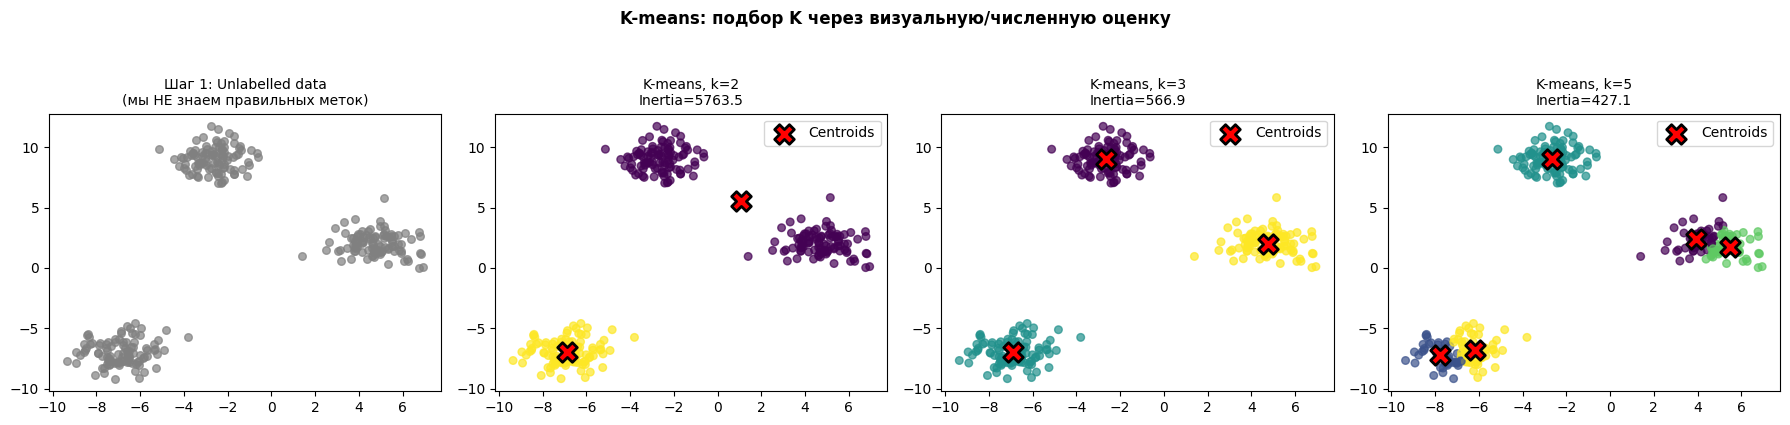

In [1]:
# Демонстрация K-means
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Генерируем 3 кластера
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Шаг 1: исходные данные
axes[0].scatter(X[:,0], X[:,1], c='gray', s=30, alpha=0.7)
axes[0].set_title('Шаг 1: Unlabelled data\n(мы НЕ знаем правильных меток)', fontsize=10)

# Шаги 2-4: K-means с k=3
for ax, k in zip(axes[1:], [2, 3, 5]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    ax.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=30, alpha=0.7)
    ax.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
               marker='X', s=200, c='red', edgecolor='black', linewidth=2, label='Centroids')
    ax.set_title(f'K-means, k={k}\nInertia={km.inertia_:.1f}', fontsize=10)
    ax.legend()

plt.suptitle('K-means: подбор K через визуальную/численную оценку',
             fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()

> 💎 **СЕКРЕТ #2 (Common mistake from Baumgarten):**
> *"Assuming clusters are globular; k-means does NOT work well with non-spherical clusters."*
>
> Поэтому KNN/K-means может **полностью провалиться** на данных типа "два полумесяца". В этих случаях используем **DBSCAN** или **Spectral**.

### 🎯 Как выбрать K? — **Elbow Method**

Строим график **inertia** (сумма квадратов расстояний до центроидов) vs K. Ищем "локоть" — точку, после которой inertia падает медленно.


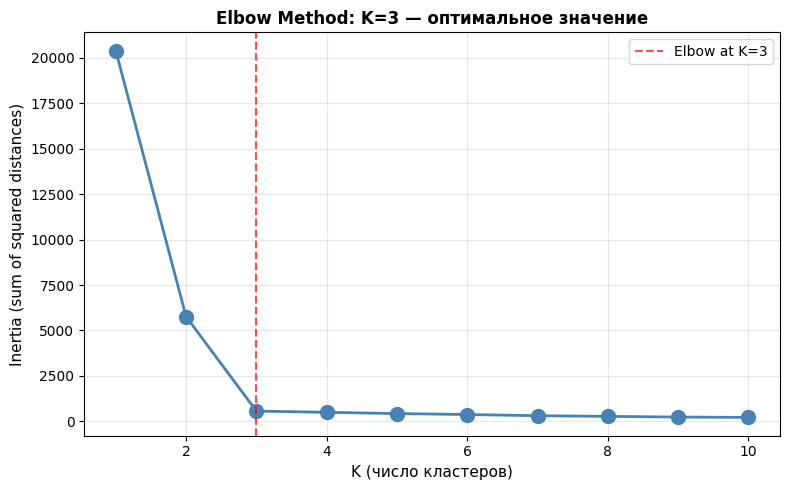

In [2]:
# Elbow method для выбора K
inertias = []
ks = range(1, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, inertias, 'o-', linewidth=2, markersize=10, color='steelblue')
ax.axvline(3, color='red', linestyle='--', alpha=0.7, label='Elbow at K=3')
ax.set_xlabel('K (число кластеров)', fontsize=11)
ax.set_ylabel('Inertia (sum of squared distances)', fontsize=11)
ax.set_title('Elbow Method: K=3 — оптимальное значение',
             fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 2️⃣ DBSCAN — Density-Based Spatial Clustering of Applications with Noise

> **Definition (Baumgarten):** *DBSCAN groups together points that are close to each other based on distance measurement and minimum number of points. It does NOT require the number of clusters to be specified in advance.*

**Ключевые отличия от K-means:**
- ✅ **Не нужно указывать K**
- ✅ Находит **произвольную форму** кластеров
- ✅ Устойчив к **выбросам** (помечает их как "noise")
- ❌ Чувствителен к параметрам **ε (eps)** и **minPts**

**Алгоритм (5 шагов — MacKenty/Stephenson):**
1. Определить параметры **ε (eps)** и **minPts**
2. Точки в радиусе ε друг от друга = "соседи"
3. Если у точки ≥ minPts соседей → она "core point" и формирует кластер
4. Расширить кластер всеми density-reachable точками
5. Точки без достаточного числа соседей → помечаются как **noise**


DBSCAN нашёл: 2 кластеров + 0 noise points


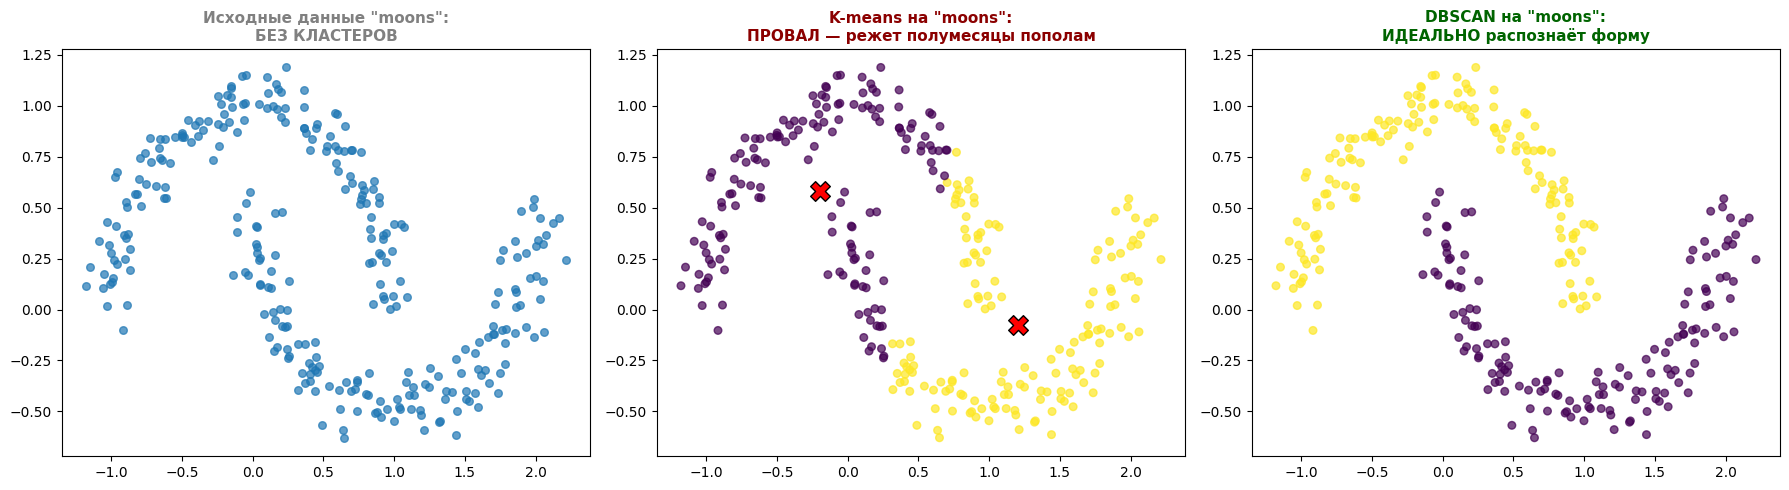

In [14]:
# DBSCAN на классическом "moons" датасете
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

X_moons, _ = make_moons(n_samples=300, noise=0.08, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Исходные данные - БЕЗ КЛАСТЕРОВ
axes[0].scatter(X_moons[:,0], X_moons[:,1], s=30, alpha=0.7)
axes[0].set_title('Исходные данные "moons":\nБЕЗ КЛАСТЕРОВ', fontsize=11, fontweight='bold', color='gray')

# K-means на этих данных — ПРОВАЛ
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = km.fit_predict(X_moons)
axes[1].scatter(X_moons[:,0], X_moons[:,1], c=km_labels, cmap='viridis', s=30, alpha=0.7)
axes[1].scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], marker='X', s=200, c='red', edgecolor='black')
axes[1].set_title('K-means на "moons":\nПРОВАЛ — режет полумесяцы пополам', fontsize=11, fontweight='bold', color='darkred')

# DBSCAN — справляется идеально
db = DBSCAN(eps=0.2, min_samples=5)
db_labels = db.fit_predict(X_moons)
axes[2].scatter(X_moons[:,0], X_moons[:,1], c=db_labels, cmap='viridis', s=30, alpha=0.7)
axes[2].set_title('DBSCAN на "moons":\nИДЕАЛЬНО распознаёт форму', fontsize=11, fontweight='bold', color='darkgreen')

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print(f"DBSCAN нашёл: {n_clusters_db} кластеров + {n_noise} noise points")

plt.tight_layout(); plt.show()

> 💎 **СЕКРЕТ #3:** *"Describe how DBSCAN differs from K-means"* — стандартный 3-балльный вопрос. Полный ответ:
> 1. DBSCAN не требует указания **числа кластеров** (k-means требует) — **1 балл**
> 2. DBSCAN находит **non-spherical clusters** (k-means только сферические) — **1 балл**
> 3. DBSCAN автоматически **помечает выбросы как noise** (k-means пытается их включить в кластер) — **1 балл**

**Применение DBSCAN:** обнаружение **мошеннических транзакций** — кластеризация по сумме/локации/времени; необычные транзакции отделяются как noise.


### 3️⃣ Hierarchical Clustering

> **Definition:** *Builds a tree of clusters (a **dendrogram**), without requiring the number of clusters to be specified in advance.*

**Два подхода:**
- **Agglomerative** (bottom-up): каждая точка — свой кластер; объединяем ближайшие.
- **Divisive** (top-down): один большой кластер; постепенно разделяем.

**Алгоритм (agglomerative, по MacKenty/Stephenson):**
1. Каждая точка — отдельный кластер
2. Объединить **2 ближайших** кластера в один
3. Пересчитать расстояния между кластерами
4. Повторять, пока всё не сольётся в один

> 💎 **Преимущество:** **дендрограмма** — можно увидеть кластеры на разных уровнях детализации.

**Применение:** генеалогия (родственные связи), таксономия в биологии, организация библиотеки.


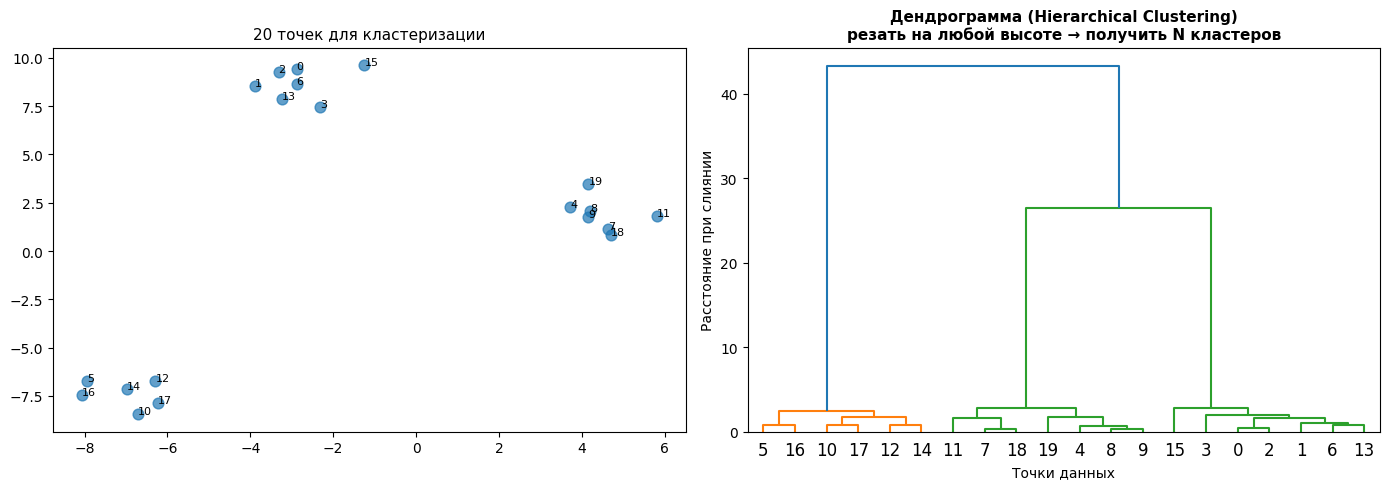

In [9]:
# Hierarchical clustering + дендрограмма
from scipy.cluster.hierarchy import dendrogram, linkage

X_small, _ = make_blobs(n_samples=20, centers=3, cluster_std=0.8, random_state=42)
Z = linkage(X_small, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_small[:,0], X_small[:,1], s=60, alpha=0.7)
for i, (x, y) in enumerate(X_small):
    axes[0].annotate(str(i), (x, y), fontsize=8)
axes[0].set_title('20 точек для кластеризации', fontsize=11)

dendrogram(Z, ax=axes[1])
axes[1].set_title('Дендрограмма (Hierarchical Clustering)\nрезать на любой высоте → получить N кластеров',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Точки данных')
axes[1].set_ylabel('Расстояние при слиянии')

plt.tight_layout(); plt.show()

### 4️⃣ Spectral Clustering

> **Definition (Baumgarten):** *Useful where clusters are NOT linearly separable. To classify a new point, it looks at where it fits best among the groups already made — like finding which circle of friends a new student would fit into.*

**Применение (по syllabus):**
- **Social network analysis** — найти сообщества в графе друзей
- Не-линейно разделимые данные

> 💎 **СЕКРЕТ #4:** Spectral использует **graph theory + eigenvectors**. Для IB **не нужно знать математику**, но **нужно знать применение** — social networks, image segmentation.

---

### 📊 Сравнительная таблица алгоритмов кластеризации (для IB Section B)

| Алгоритм | Указывать K? | Форма кластеров | Шум/outliers | Скорость | Лучший use case |
|---|---|---|---|---|---|
| **K-means** | **Да** | сферическая | плохо | быстро | сегментация клиентов |
| **DBSCAN** | Нет | **любая** | **отлично** | средне | fraud detection |
| **Hierarchical** | Нет | любая | средне | **медленно** | таксономия, genealogy |
| **Spectral** | Да | non-linear | средне | медленно | social networks |

> 💎 **СЕКРЕТ #5:** *"Which clustering algorithm would you use for [scenario]?"* — структура ответа:
> 1. Назвать алгоритм
> 2. Обосновать через **характеристики данных** (форма, шум, известно ли K)
> 3. Один альтернативный + почему он хуже


## 🛒 Часть 2 · A4.3.5 Association Rule Learning

> **Definition (Baumgarten):** *Association rule is a process of finding patterns of co-occurrence in data; given the presence of one item, how likely it is that another item will be present.*

**Это тоже unsupervised learning!** Меток нет — мы просто ищем, **что часто покупают вместе**.

### 🎯 Классический пример: Market Basket Analysis

> Транзакции в супермаркете: ${ \{milk, bread\}, \{milk, butter, eggs\}, \{bread, butter\}, ... }$
>
> Цель: найти правила вида **{X} → {Y}** ("кто купил X, скорее всего купит Y").

---

### 📐 Три метрики (ОБЯЗАТЕЛЬНО выучить!)

> На экзамене эти 3 метрики могут попросить **рассчитать вручную**.

**Допустим: 1000 транзакций, в 600 есть milk, в 400 есть bread, в 300 есть оба.**

| Метрика | Формула | Расчёт | Интерпретация |
|---|---|---|---|
| **Support({Milk, Bread})** | $\frac{\text{trans. with both}}{\text{total trans.}}$ | $\frac{300}{1000} = 0.30$ | 30% транзакций содержат оба товара |
| **Confidence(Milk → Bread)** | $\frac{\text{Support}(\{M, B\})}{\text{Support}(\{M\})}$ | $\frac{300/1000}{600/1000} = 0.50$ | 50% покупателей молока также покупают хлеб |
| **Lift(Milk → Bread)** | $\frac{\text{Confidence}(M \to B)}{\text{Support}(\{B\})}$ | $\frac{0.50}{0.40} = 1.25$ | в 1.25× **чаще** вместе, чем случайно |

> 💎 **СЕКРЕТ #6 — интерпретация Lift:**
> - **Lift > 1** → положительная связь (X **увеличивает** вероятность Y)
> - **Lift = 1** → независимы (X **не влияет** на Y)
> - **Lift < 1** → отрицательная связь (X **снижает** вероятность Y)
>
> На экзамене *"Define lift"* **[1]** — это **гарантированный балл**.


In [10]:
# Демонстрация Apriori на синтетических транзакциях
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Транзакции в формате list of lists
transactions = [
    ['milk', 'bread', 'butter'],
    ['milk', 'bread'],
    ['milk', 'butter'],
    ['bread', 'butter'],
    ['milk', 'bread', 'butter', 'eggs'],
    ['eggs', 'milk'],
    ['bread', 'jam'],
    ['milk', 'bread', 'jam'],
    ['butter', 'eggs'],
    ['milk', 'bread', 'butter'],
]

# Преобразуем в "one-hot" таблицу
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)
print("=== Транзакции (one-hot) ===")
print(df.astype(int))

# Apriori: найти все itemsets с support >= 0.3
frequent_itemsets = apriori(df, min_support=0.3, use_colnames=True)
print("\n=== Frequent itemsets (support >= 0.3) ===")
print(frequent_itemsets.sort_values('support', ascending=False))

# Association rules: confidence >= 0.6
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.6)
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False)
print("\n=== Top Association Rules ===")
print(rules.head(10).round(3))

=== Транзакции (one-hot) ===
   bread  butter  eggs  jam  milk
0      1       1     0    0     1
1      1       0     0    0     1
2      0       1     0    0     1
3      1       1     0    0     0
4      1       1     1    0     1
5      0       0     1    0     1
6      1       0     0    1     0
7      1       0     0    1     1
8      0       1     1    0     0
9      1       1     0    0     1

=== Frequent itemsets (support >= 0.3) ===
   support               itemsets
0      0.7                (bread)
3      0.7                 (milk)
1      0.6               (butter)
5      0.5          (milk, bread)
6      0.4         (milk, butter)
4      0.4        (bread, butter)
2      0.3                 (eggs)
7      0.3  (milk, bread, butter)

=== Top Association Rules ===
       antecedents consequents  support  confidence   lift
6  (bread, butter)      (milk)      0.3       0.750  1.071
5   (milk, butter)     (bread)      0.3       0.750  1.071
1           (milk)     (bread)      0.5

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 🔄 Алгоритм Apriori (по MacKenty/Stephenson, стр. 283)

1. **Set minimum support and confidence** thresholds
2. **Generate candidate itemsets** — начинаем с одиночных товаров (frequent items)
3. **Determine frequent itemsets** — считаем support, оставляем те, что >= threshold
4. **Create higher-order itemsets** — пары, тройки и т.д., объединяя frequent items
5. **Generate association rules** — из frequent itemsets создаём правила
6. **Rule pruning** — удаляем правила с низкой confidence

> 💎 **СЕКРЕТ #7 (Apriori principle):** *"If an itemset is infrequent, then all its supersets are also infrequent."*
> — Это **главная оптимизация**: можем **отбросить** большие комбинации, если их подмножества не прошли threshold.

### 🌐 Реальные применения (для IB ответов)

| Сценарий | Что находим |
|---|---|
| **Market basket** | какие товары покупают вместе |
| **Fraud detection** | необычные сочетания транзакций |
| **Web behaviour** | какие страницы посещают подряд |
| **Crime analysis** | сочетания преступлений (vandalism → theft) |
| **Healthcare** | сочетания симптомов |
| **Library** | какие книги берут вместе |


## 🏆 Часть 3 · A4.3.10 Model Selection and Comparison

> **Definition (Baumgarten):** *Model selection is the process of choosing the most appropriate ML algorithm for a given problem; comparison evaluates multiple models against each other using metrics.*

### 🎯 Почему это важно?

> Из MacKenty/Stephenson: *"Each ML algorithm makes different assumptions about the data, which can greatly affect their performance."*

**На вопрос "какую модель использовать?" — нет одного ответа.** Зависит от:

### 5 факторов выбора модели

| Фактор | Что значит для выбора |
|---|---|
| **Nature of problem** | классификация → KNN/DT/SVM; регрессия → LR/Random Forest |
| **Complexity** | простые модели → быстрее, легче понять; сложные → могут лучше работать |
| **Data quantity/quality** | мало данных → KNN/LR; много → нейросети |
| **Performance metrics** | accuracy vs precision vs recall — зависит от стоимости ошибок |
| **Computational resources** | edge device → простая модель; cloud → можно сложную |

> 💎 **СЕКРЕТ #8:** *"Identify three factors that should be considered in model selection"* **[3]** (Baumgarten Review #20). Просто перечислите 3 из таблицы выше — **гарантированные 3 балла**.


### 📊 Cross-Validation — gold standard для model selection

> **Definition (Baumgarten Review #19):** *Cross-validation involves splitting data into multiple folds, training on some, testing on others, and averaging results.*

**Зачем нужна CV?**
- Одно train/test split может быть **"везучим"** — модель выглядит лучше, чем есть
- **K-fold CV** обучает модель **K раз** на разных частях → надёжная оценка
- **Стандарт:** K = 5 или K = 10


=== 5-fold Cross-Validation (F1 score) ===

KNN (k=5)                : F1 = 0.8377 ± 0.0431
Decision Tree            : F1 = 0.7669 ± 0.0357
Logistic Regression      : F1 = 0.8033 ± 0.0287


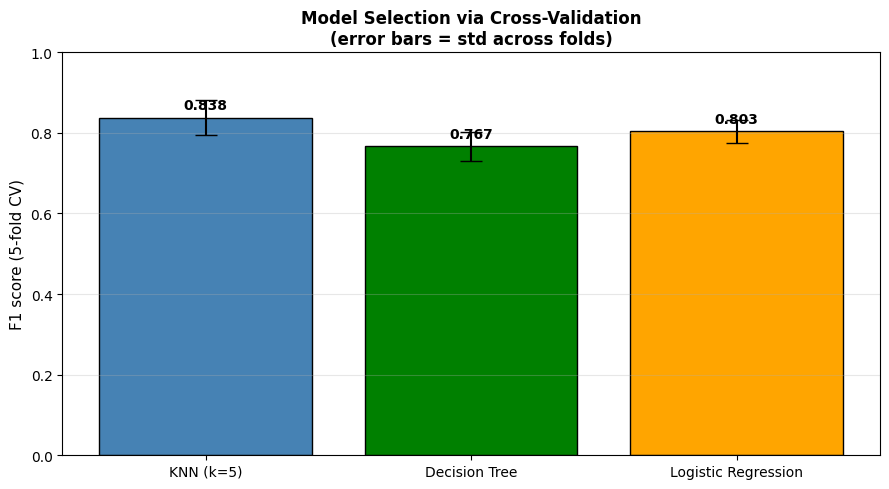

In [17]:
# Демо: 5-fold cross-validation
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import matplotlib.pyplot as plt

X_cv, y_cv = make_classification(n_samples=300, n_features=10, n_informative=5,
                                  random_state=42)

models = {
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000),
}

print("=== 5-fold Cross-Validation (F1 score) ===\n")
results = []
for name, model in models.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring='f1')
    results.append({'Model': name, 'Mean F1': scores.mean(), 'Std': scores.std()})
    print(f"{name:25s}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

# Визуализация
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(results_df['Model'], results_df['Mean F1'],
              yerr=results_df['Std'], capsize=8,
              color=['steelblue', 'green', 'orange'], edgecolor='black')
ax.set_ylabel('F1 score (5-fold CV)', fontsize=11)
ax.set_title('Model Selection via Cross-Validation\n(error bars = std across folds)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Подписи значений
for bar, score in zip(bars, results_df['Mean F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', fontweight='bold')

plt.tight_layout(); plt.show()

### 🏆 Финальная структура Model Selection отчёта (для IA + Section B)

```
1. Problem definition
   - Classification / Regression / Clustering?
   - Metric to optimize (accuracy / F1 / recall / R²)

2. Models considered
   - List 2-3 алгоритмов с обоснованием выбора

3. Evaluation
   - Cross-validation results (mean ± std)
   - Confusion matrices (для классификации)
   - Hyperparameter tuning curves

4. Comparison criteria (минимум 4):
   - Performance (метрика)
   - Interpretability
   - Training/prediction speed
   - Risk of overfitting

5. Final recommendation
   - Какую модель деплоить + ПОЧЕМУ
   - Trade-off явно обозначен
```

> 💎 **СЕКРЕТ #9:** на IB *"Justify which model should be deployed"* **[6]** — **обязательно** включите:
> 1. Конкретные численные результаты (F1, CV mean)
> 2. Сравнение по 4+ критериям
> 3. Trade-off (что теряем, выбирая модель A вместо B)
> 4. **Контекст применения** (медицина → recall, скорость → KNN или нет)


## 📝 Часть 4 · Mini Exam Practice (в классе)

### Вопрос 1 (Baumgarten Review #9, p. 38)
> *An online retailer uses k-means clustering to segment customers based on purchasing patterns.*
>
> **a)** *Outline* the objective of the k-means clustering algorithm. **[2]**
> **b)** *Describe* one challenge when using k-means clustering for customer segmentation. **[3]**
> **c)** *Describe* how the choice of k affects the outcomes of the k-means algorithm. **[3]**

> 💎 **Разбор (a) [2]:** 1) Партиционирует данные на K кластеров; 2) минимизируя расстояние до центроидов.
>
> 💎 **Разбор (b) [3]:** Чувствительность к выбору K (нужно угадать); чувствительность к outliers; предполагает **сферические** кластеры (не работает с complex shapes).

---

### Вопрос 2 (Baumgarten Review #11, p. 38)
> *A social-media company uses clustering to identify social groups on its network system.*
>
> **a)** *Identify* which clustering algorithm would allow identification of social groups. **[1]**
> **b)** *Describe* one potential challenge in clustering users based on diverse data. **[3]**

> 💎 **(a):** **Spectral clustering** — лучший для social networks (graph-based).

---

### Вопрос 3 (Baumgarten Review #13, p. 38)
> *An e-commerce platform analyses user purchasing data.*
>
> **a)** *Define* "lift" in association rule mining. **[2]**
> **b)** *Describe* how minimum support and confidence levels affect rules generated. **[3]**

> 💎 **(a) на 2/2:** Lift is the ratio of observed support to expected support if the two items were independent (1 балл). Lift > 1 indicates items appear together more frequently than expected by chance (1 балл).

---

### Вопрос 4 (Baumgarten Review #19, p. 39 — model selection)
> *A tech company experiments with several ML models to predict user engagement.*
>
> **a)** *Define* "model selection". **[1]**
> **b)** *Identify* two metrics that could be used to select the best model. **[2]**
> **c) i)** *Outline* the concept of cross-validation. **[2]**
> **c) ii)** *Describe* one reason why it is important in model selection. **[2]**

> 💎 **(c.ii) образец:** *"Cross-validation provides a more reliable estimate of model performance by averaging across multiple train/test splits, reducing the risk of selecting a model that happened to perform well on a single 'lucky' split."*


## ✅ Чек-лист после Урока 5

К следующему уроку вы должны:

### A4.3.4 Clustering
- [ ] Знать **определение clustering** + чем отличается от classification
- [ ] **4 шага K-means** (initialize → assign → recalculate → repeat)
- [ ] Знать **5 шагов DBSCAN** + параметры (ε, minPts)
- [ ] Объяснить **разницу K-means vs DBSCAN** в 3 пунктах
- [ ] Знать когда какой алгоритм использовать (таблица сравнения)

### A4.3.5 Association Rules
- [ ] **3 метрики наизусть**: Support, Confidence, Lift + формулы
- [ ] **Уметь считать** их по числам в Worked Example
- [ ] Знать **алгоритм Apriori** (6 шагов)
- [ ] Знать 3 применения

### A4.3.10 Model Selection
- [ ] **5 факторов** выбора модели (problem nature, complexity, data, metrics, resources)
- [ ] Что такое **Cross-Validation** и зачем
- [ ] Структура **отчёта Model Selection** для IA

---

### 📚 ДЗ (см. `Week3_HW1_Theory.ipynb`)

1. Расчёт support/confidence/lift **вручную** на новом сценарии
2. Comparison: K-means vs DBSCAN vs Hierarchical
3. Sample paper: case study с model selection
4. IB exam practice вопросы

---

> 🎓 **Финальный секрет Урока 5:**
> Unsupervised learning часто **недооценивают** студенты, потому что нет привычной метрики "accuracy".
> Но на IB Section B **минимум 1 вопрос** обычно про clustering или association rules.
> **Запомните metrics формулы наизусть** — за них дают баллы автоматически.
